# Extract graded solutions

Choose one assignment below. The notebook joins its rubric rows to the final submitted programming snapshot and builds a `solutions` list for further processing.

In [70]:
# Hyperparameters: select the task and student to analyze.
TASK_ID = "squiralHW"
STUDENT_ID = "J7u.Zn25F3jN.IqS"  # Set an anonymized student ID, or None for the shortest trace.
EXCLUDE_SELECTED_STUDENT = False  # Avoid using the student's own final solution as a reference.
GRADE_METHOD = "distance_weighted"  # Use "distance_weighted" or "nearest".
DISTANCE_DECAY = 1.00  # Larger values make distant exemplars lose influence faster.

# Paths assume the notebook is launched from the repository root.
DATA_DIR = "data"

Available graded tasks are `polygonMakerLab`, `squiralHW`, `guess1Lab`, `guess2HW`, and `guess3Lab`. The Lights, Camera, Action assignment has no rubric CSV.

In [71]:
import csv
import json
import math
import sqlite3
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
from snap_ast import to_ast, to_ast_with_values, tree_edit_distance

data_dir = Path(DATA_DIR)
if not data_dir.is_dir() and (Path.cwd().parent / DATA_DIR).is_dir():
    data_dir = Path.cwd().parent / DATA_DIR

history_db = data_dir / ".learnlab-history.sqlite3"
rubric_path = data_dir / f"{TASK_ID}.csv"

if not history_db.is_file():
    raise FileNotFoundError(
        f"Missing {history_db}. Run `uv run learnlab-team5 --no-browser` once to build it."
    )
if not rubric_path.is_file():
    raise ValueError(f"Task {TASK_ID!r} has no rubric file at {rubric_path}")

## Load the task rubric

Rubric scores use the dataset's 0–2 scale. `Graded ID` and free-text comments are intentionally excluded.

In [72]:
with rubric_path.open(newline="", encoding="utf-8-sig") as source:
    reader = csv.DictReader(source)
    rubric_columns = [
        column
        for column in (reader.fieldnames or [])
        if column not in {"Project ID", "Graded ID"}
        and column.strip().lower() != "comment"
    ]
    rubric_rows = list(reader)

if not rubric_columns:
    raise ValueError(f"No rubric columns found in {rubric_path}")

rubric_by_project = {}
for row in rubric_rows:
    project_id = row["Project ID"]
    if project_id in rubric_by_project:
        raise ValueError(f"Duplicate rubric project ID: {project_id}")
    rubric_by_project[project_id] = row

print(f"Loaded {len(rubric_rows)} rubric rows and {len(rubric_columns)} criteria.")

Loaded 44 rubric rows and 6 criteria.


## Find each student's graded solution

For these data, every student–task pair has exactly one `Project.Submit` event, and its code state equals the final trace state. The query therefore selects the last snapshot for each student in the chosen task and joins its actual AST and pseudocode.

In [73]:
database_uri = f"file:{history_db.resolve().as_posix()}?mode=ro"
with sqlite3.connect(database_uri, uri=True) as connection:
    connection.row_factory = sqlite3.Row
    final_rows = connection.execute(
        """
        WITH ranked_steps AS (
            SELECT
                assignment_id,
                subject_id,
                project_id,
                step_index,
                event_id,
                client_timestamp,
                code_state_id,
                ROW_NUMBER() OVER (
                    PARTITION BY assignment_id, subject_id
                    ORDER BY step_index DESC
                ) AS position
            FROM timeline_steps
            WHERE assignment_id = ?
        )
        SELECT
            r.subject_id,
            r.project_id,
            r.step_index,
            r.event_id,
            r.client_timestamp,
            r.code_state_id,
            c.ast_json,
            c.pseudocode
        FROM ranked_steps AS r
        JOIN code_states AS c USING (code_state_id)
        WHERE r.position = 1
        ORDER BY r.subject_id
        """,
        (TASK_ID,),
    ).fetchall()

final_by_project = {row["project_id"]: row for row in final_rows}
print(f"Found {len(final_rows)} final programming snapshots for {TASK_ID}.")

Found 44 final programming snapshots for squiralHW.


## Build `solutions`

Each list item contains identifiers, the parsed source AST, pseudocode, canonical `snap_ast` trees, individual rubric scores, and aggregate grade fields. Rubric rows with no recorded score at all are excluded; partially missing rubrics retain `None` for the missing items.

In [74]:
def parse_score(raw_value):
    value = raw_value.strip()
    return float(value) if value else None


solutions = []
rubrics_without_trace = []
rubrics_without_scores = []

for project_id, rubric_row in rubric_by_project.items():
    final = final_by_project.get(project_id)
    if final is None:
        rubrics_without_trace.append(project_id)
        continue

    rubric_scores = {
        criterion: parse_score(rubric_row[criterion])
        for criterion in rubric_columns
    }
    recorded_scores = [score for score in rubric_scores.values() if score is not None]
    if not recorded_scores:
        rubrics_without_scores.append(project_id)
        continue

    ast_json = final["ast_json"]
    solutions.append(
        {
            "student_id": final["subject_id"],
            "task_id": TASK_ID,
            "project_id": project_id,
            "code_state_id": final["code_state_id"],
            "step_index": final["step_index"],
            "event_id": final["event_id"],
            "timestamp": final["client_timestamp"],
            "ast": json.loads(ast_json) if ast_json else None,
            "rubric_scores": rubric_scores,
        }
    )

solutions.sort(key=lambda solution: solution["student_id"].lower())

solutions

[{'student_id': '.B.pVmLkRJSVP/o6',
  'task_id': 'squiralHW',
  'project_id': '95d5d616-14e0-4594-af6c-3c98afdc5b41',
  'code_state_id': '15720',
  'step_index': 201,
  'event_id': 55303,
  'timestamp': '2017-02-06T23:44:21',
  'ast': {'type': 'snapshot',
   'id': '95d5d616-14e0-4594-af6c-3c98afdc5b41',
   'children': [{'type': 'stage',
     'value': 'Stage',
     'id': 'stage',
     'children': [{'type': 'sprite',
       'value': 'Sprite',
       'id': 'Sprite',
       'children': [{'type': 'script',
         'children': [{'type': 'receiveGo', 'id': '74'},
          {'type': 'evaluateCustomBlock',
           'value': 'squiral %s %s',
           'id': '689',
           'children': [{'type': 'literal', 'value': '5'},
            {'type': 'literal', 'value': '10'}]}]}]}]},
    {'type': 'customBlock',
     'value': 'squiral %s %s',
     'id': 'c5eb0578-ef90-4fdc-a075-ec22c59217c1',
     'children': [{'type': 'script',
       'children': [{'type': 'clear', 'id': '770'},
        {'type': 'd

The `solutions` variable is now ready for subsequent processing. This final cell previews one item without printing the complete AST.

## Estimate a student's grade throughout the trace

`estimate_grades_from_distances` is the reusable estimator: it computes the tree-edit distance from one snapshot to every graded reference solution, then estimates each rubric criterion independently. The aggregate estimate is the sum of those criterion estimates. `closest_graded_solution_grade` returns the grade of the nearest reference. `distance_weighted_average_grade` averages reference grades with exponentially decreasing weights. `DISTANCE_DECAY = 0` gives every exemplar equal weight; larger values make the estimate concentrate more sharply on nearby exemplars. References with a missing score for a criterion are omitted only from that criterion's estimate.

Distances use opcode-only canonical ASTs. Node values and trace-specific IDs therefore do not affect this example.

In [75]:
def rubric_total(solution):
    """Sum the recorded rubric points for one graded solution."""
    return sum(
        score
        for score in solution["rubric_scores"].values()
        if score is not None
    )


def closest_graded_solution_grade(distances, grades):
    """Return the grade belonging to the closest reference solution."""
    if not distances or len(distances) != len(grades):
        raise ValueError("distances and grades must be nonempty and equally sized")
    closest_index = min(range(len(distances)), key=distances.__getitem__)
    return grades[closest_index]


def distance_weighted_average_grade(distances, grades, distance_decay):
    """Average grades with weights that fall exponentially with AST distance.

    Subtracting the minimum distance before exponentiation is numerically stable
    and does not change the normalized weighted average.
    """
    if not distances or len(distances) != len(grades):
        raise ValueError("distances and grades must be nonempty and equally sized")
    if not math.isfinite(distance_decay) or distance_decay < 0:
        raise ValueError("distance_decay must be a finite nonnegative number")

    nearest_distance = min(distances)
    weights = [
        math.exp(-distance_decay * (distance - nearest_distance))
        for distance in distances
    ]
    total_weight = sum(weights)
    return sum(weight * grade for weight, grade in zip(weights, grades)) / total_weight


def configured_grade_function(distances, grades):
    """Apply the grading method selected in the parameter cell."""
    if GRADE_METHOD == "nearest":
        return closest_graded_solution_grade(distances, grades)
    if GRADE_METHOD == "distance_weighted":
        return distance_weighted_average_grade(distances, grades, DISTANCE_DECAY)
    raise ValueError("GRADE_METHOD must be 'nearest' or 'distance_weighted'")


grade_estimator_label = (
    "Nearest-solution estimate"
    if GRADE_METHOD == "nearest"
    else f"Distance-weighted estimate (decay={DISTANCE_DECAY:g})"
)


def estimate_grades_from_distances(solution_ast, graded_references, grade_function):
    """Estimate each rubric score and their aggregate from AST distances.

    ``grade_function`` receives two parallel lists: distances and grades.
    The returned distance list is useful for inspecting the chosen neighbors.
    """
    if not graded_references:
        raise ValueError("at least one graded reference solution is required")
    canonical_solution = to_ast_with_values(solution_ast)
    distances = [
        tree_edit_distance(canonical_solution, reference["canonical_ast"])
        for reference in graded_references
    ]
    rubric_estimates = {}
    for criterion in rubric_columns:
        scored_references = [
            (distance, reference["rubric_scores"].get(criterion))
            for distance, reference in zip(distances, graded_references)
            if reference["rubric_scores"].get(criterion) is not None
        ]
        if not scored_references:
            rubric_estimates[criterion] = None
            continue
        criterion_distances, criterion_grades = zip(*scored_references)
        rubric_estimates[criterion] = grade_function(
            list(criterion_distances),
            list(criterion_grades),
        )

    available_estimates = [
        estimate for estimate in rubric_estimates.values() if estimate is not None
    ]
    if not available_estimates:
        raise ValueError("no rubric scores are available in the reference solutions")
    aggregate_estimate = sum(available_estimates)
    return aggregate_estimate, rubric_estimates, distances


# Canonicalize graded solutions once; these trees are reused for every trace step.
graded_references = [
    {
        "student_id": solution["student_id"],
        "project_id": solution["project_id"],
        "canonical_ast": to_ast(solution["ast"]),
        "grade": rubric_total(solution),
        "rubric_scores": solution["rubric_scores"],
    }
    for solution in solutions
    if solution["ast"] is not None
]

print(f"Prepared {len(graded_references)} graded reference solutions.")

Prepared 43 graded reference solutions.


The next cell selects `STUDENT_ID`, loads every AST-bearing snapshot in that student's trace, and estimates its aggregate grade and individual rubric points at every step. The upper plot shows the aggregate score; the lower plot shows one line per rubric criterion, with X markers for the student's actual final rubric scores. When `STUDENT_ID` is `None`, the shortest graded trace is selected so the example runs quickly.

Estimated 25/87 trace steps
Estimated 50/87 trace steps
Estimated 75/87 trace steps
Estimated 87/87 trace steps


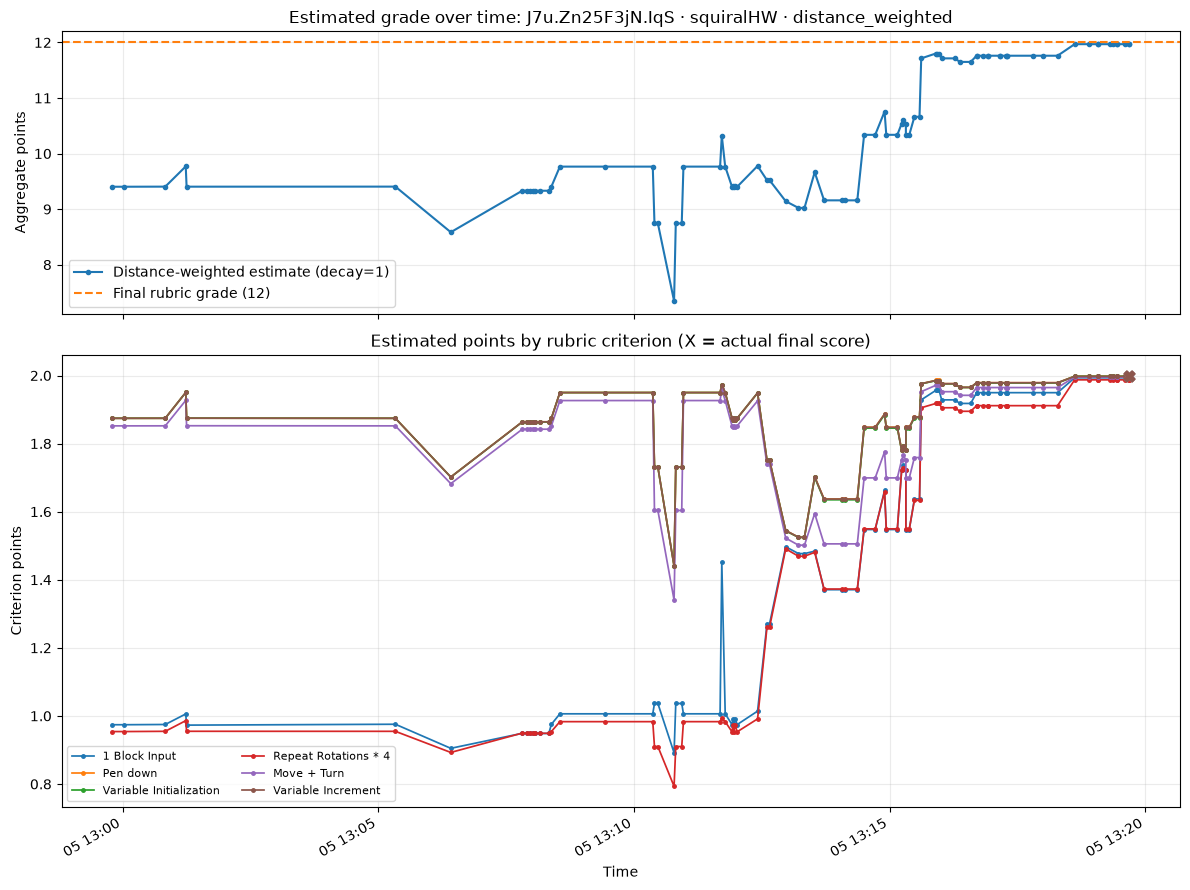

{'student_id': 'J7u.Zn25F3jN.IqS',
 'grade_method': 'distance_weighted',
 'distance_decay': 1.0,
 'trace_steps_plotted': 87,
 'reference_solutions': 43,
 'actual_final_grade': 12.0,
 'first_estimate': 9.403255131849011,
 'last_estimate': 11.969019133246613,
 'last_rubric_estimates': {'1 Block Input': 1.9932740411249656,
  'Pen down': 1.9977563443072255,
  'Variable Initialization': 1.9977154394692247,
  'Repeat Rotations * 4': 1.9872792409914277,
  'Move + Turn': 1.9955379498701546,
  'Variable Increment': 1.9974561174836152}}

In [76]:
graded_student_ids = {solution["student_id"] for solution in solutions}

with sqlite3.connect(database_uri, uri=True) as connection:
    connection.row_factory = sqlite3.Row
    trace_sizes = connection.execute(
        """
        SELECT subject_id, COUNT(*) AS step_count
        FROM timeline_steps
        WHERE assignment_id = ?
        GROUP BY subject_id
        ORDER BY step_count, subject_id
        """,
        (TASK_ID,),
    ).fetchall()

    if STUDENT_ID is None:
        selected_student_id = next(
            row["subject_id"]
            for row in trace_sizes
            if row["subject_id"] in graded_student_ids
        )
    else:
        selected_student_id = STUDENT_ID

    if selected_student_id not in {row["subject_id"] for row in trace_sizes}:
        raise ValueError(
            f"Student {selected_student_id!r} has no trace for task {TASK_ID!r}"
        )

    trace_rows = connection.execute(
        """
        SELECT
            t.step_index,
            t.event_id,
            t.client_timestamp,
            t.code_state_id,
            c.ast_json
        FROM timeline_steps AS t
        JOIN code_states AS c USING (code_state_id)
        WHERE t.assignment_id = ?
          AND t.subject_id = ?
          AND c.ast_json IS NOT NULL
        ORDER BY t.step_index
        """,
        (TASK_ID, selected_student_id),
    ).fetchall()

references_for_student = [
    reference
    for reference in graded_references
    if not EXCLUDE_SELECTED_STUDENT
    or reference["student_id"] != selected_student_id
]
if not references_for_student:
    raise ValueError("No graded reference solutions remain after filtering")

estimated_trace = []
estimate_cache = {}  # Reuse results when undo/redo revisits a code state.
for trace_position, row in enumerate(trace_rows, start=1):
    if row["code_state_id"] not in estimate_cache:
        estimate_cache[row["code_state_id"]] = estimate_grades_from_distances(
            row["ast_json"],
            references_for_student,
            configured_grade_function,
        )
    estimated_grade, rubric_estimates, distances = estimate_cache[row["code_state_id"]]
    closest_index = min(range(len(distances)), key=distances.__getitem__)
    closest_reference = references_for_student[closest_index]
    estimated_trace.append(
        {
            "step_index": row["step_index"],
            "event_id": row["event_id"],
            "time": datetime.fromisoformat(row["client_timestamp"]),
            "code_state_id": row["code_state_id"],
            "estimated_grade": estimated_grade,
            "estimated_rubric_scores": rubric_estimates,
            "nearest_distance": distances[closest_index],
            "nearest_student_id": closest_reference["student_id"],
        }
    )
    if trace_position % 25 == 0 or trace_position == len(trace_rows):
        print(f"Estimated {trace_position}/{len(trace_rows)} trace steps")

actual_solution = next(
    (solution for solution in solutions if solution["student_id"] == selected_student_id),
    None,
)
actual_grade = rubric_total(actual_solution) if actual_solution else None

actual_rubric_scores = actual_solution["rubric_scores"] if actual_solution else {}

figure, (aggregate_axis, rubric_axis) = plt.subplots(
    2,
    1,
    figsize=(12, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1.6]},
)
times = [step["time"] for step in estimated_trace]

aggregate_axis.plot(
    times,
    [step["estimated_grade"] for step in estimated_trace],
    marker="o",
    markersize=3,
    linewidth=1.5,
    label=grade_estimator_label,
)
if actual_grade is not None:
    aggregate_axis.axhline(
        actual_grade,
        color="tab:orange",
        linestyle="--",
        label=f"Final rubric grade ({actual_grade:g})",
    )
aggregate_axis.set_title(
    f"Estimated grade over time: {selected_student_id} · {TASK_ID} · {GRADE_METHOD}"
)
aggregate_axis.set_ylabel("Aggregate points")
aggregate_axis.grid(alpha=0.25)
aggregate_axis.legend()

for criterion in rubric_columns:
    criterion_estimates = [
        step["estimated_rubric_scores"][criterion]
        for step in estimated_trace
    ]
    line, = rubric_axis.plot(
        times,
        criterion_estimates,
        marker="o",
        markersize=2.5,
        linewidth=1.25,
        label=criterion,
    )
    actual_score = actual_rubric_scores.get(criterion)
    if actual_score is not None:
        rubric_axis.scatter(
            times[-1],
            actual_score,
            color=line.get_color(),
            marker="X",
            s=55,
            zorder=3,
        )

rubric_axis.set_title("Estimated points by rubric criterion (X = actual final score)")
rubric_axis.set_xlabel("Time")
rubric_axis.set_ylabel("Criterion points")
rubric_axis.grid(alpha=0.25)
rubric_axis.legend(ncol=2, fontsize=8)
figure.autofmt_xdate()
figure.tight_layout()
plt.show()

{
    "student_id": selected_student_id,
    "grade_method": GRADE_METHOD,
    "distance_decay": DISTANCE_DECAY if GRADE_METHOD == "distance_weighted" else None,
    "trace_steps_plotted": len(estimated_trace),
    "reference_solutions": len(references_for_student),
    "actual_final_grade": actual_grade,
    "first_estimate": estimated_trace[0]["estimated_grade"],
    "last_estimate": estimated_trace[-1]["estimated_grade"],
    "last_rubric_estimates": estimated_trace[-1]["estimated_rubric_scores"],
}